# Human-skill structure — correlation & multivariate analysis

Reads `skill-metrics.csv` (from `analyze_skills.py`) and explores how the human-curated **skill-structure metrics** relate to each other, to task difficulty, and to the `structure_class` axis used for stratified sampling in the *human-curated vs AIP-from-curated* study.

1. **Correlation heatmap** (Spearman — robust to heavy-tailed LoC counts).
2. **Pairwise scatter + regression matrix** across the key structure metrics.
3. The same matrix **colored by `structure_class`** to see how prose-only / mixed / script-heavy groups separate.

## Metrics dictionary

Columns in `skill-metrics.csv` (one row per task), produced by `analyze_skills.py` from each task's human-curated skills under `vendor/skillsbench/tasks/<task>/environment/skills/`.

| column | type | meaning |
|---|---|---|
| `task` | str | task name (dir under `vendor/skillsbench/tasks/`) |
| `difficulty` | cat | `easy` / `medium` / `hard`, from `task.toml` (human-estimated, not model difficulty) |
| `category` | cat | controlled domain category, from `task.toml` |
| `description` | str | first sentence of the task's `instruction.md` |
| `structure_class` | cat | **AIP-upside axis** — `prose-only` (no scripts; highest upside), `mixed` (scripts < prose), `script-heavy` (scripts ≥ prose; lowest upside), `none` (no curated skill) |
| `n_skills` | int | number of curated skill dirs (each with a `SKILL.md`) bundled with the task |
| `skill_names` | str | `;`-joined skill dir names |
| `skill_md_loc` | int | total lines across all `SKILL.md` files — the procedure *prose* |
| `n_scripts` | int | count of executable files (under `scripts/`, or code extensions `.py/.sh/.js/...`) |
| `script_loc` | int | total lines across those scripts — the *executable* knowledge |
| `n_refs` | int | count of reference docs (`references/`, other `.md`/`.txt`) |
| `ref_loc` | int | total lines across reference docs |
| `n_assets` | int | non-code, non-doc bundled files (data, images, templates) |
| `prose_loc` | int | `skill_md_loc + ref_loc` — total human-readable text the agent must absorb |
| `prose_to_code_ratio` | float | `prose_loc / script_loc` — high = prose-heavy (more AIP upside); blank when `script_loc == 0` |
| `total_files` | int | all files in the task's skill set |
| `total_kb` | float | total size of the skill set, KB |

**Derived in this notebook:** `difficulty_ord` = `easy`→0, `medium`→1, `hard`→2 (ordinal encoding so difficulty can enter the correlation matrix).

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")

csv = Path("skill-metrics.csv")
if not csv.exists():
    csv = Path("skill-analysis/skill-metrics.csv")
df = pd.read_csv(csv)
df["difficulty_ord"] = df["difficulty"].map({"easy": 0, "medium": 1, "hard": 2})

metrics = ["n_skills", "skill_md_loc", "n_scripts", "script_loc",
           "n_refs", "ref_loc", "n_assets", "prose_loc", "total_files", "difficulty_ord"]
num = df[metrics].apply(pd.to_numeric, errors="coerce")
print(f"{len(df)} tasks loaded")
num.describe().T.round(1)

95 tasks loaded


,count,mean,std,min,25%,50%,75%,max
n_skills,95.0,2.7,1.5,1.0,1.0,2.0,3.0,7.0
skill_md_loc,95.0,541.0,484.2,20.0,249.0,373.0,638.5,2190.0
n_scripts,95.0,2.5,5.3,0.0,0.0,0.0,3.0,39.0
script_loc,95.0,517.3,1371.4,0.0,0.0,0.0,284.0,9384.0
n_refs,95.0,2.9,7.9,0.0,0.0,0.0,3.0,50.0
ref_loc,95.0,649.1,1615.5,0.0,0.0,0.0,632.5,10894.0
n_assets,95.0,1.9,9.7,0.0,0.0,0.0,0.0,78.0
prose_loc,95.0,1190.1,1788.8,20.0,275.0,471.0,1298.0,11494.0
total_files,95.0,10.0,17.5,1.0,3.0,5.0,10.0,136.0
difficulty_ord,95.0,1.3,0.6,0.0,1.0,1.0,2.0,2.0


## Correlation heatmap

Spearman rank correlation — the LoC/count metrics are heavy-tailed (a few tasks carry thousands of script lines, many carry zero), so rank correlation is more meaningful than Pearson. `difficulty_ord` (easy=0, medium=1, hard=2) is included to check whether structure tracks difficulty or is an independent axis.

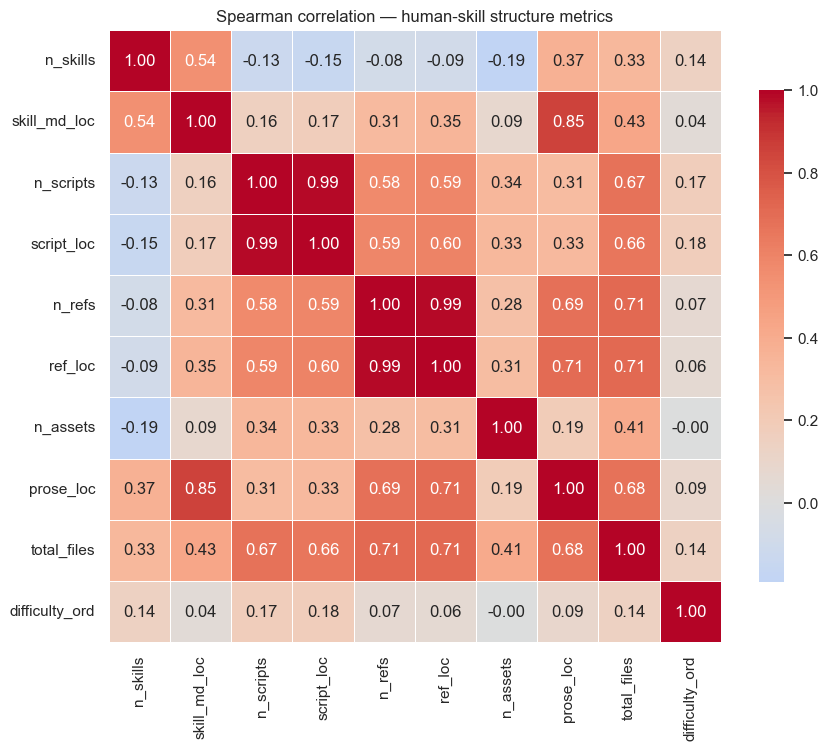

In [2]:
corr = num.corr(method="spearman")
plt.figure(figsize=(9, 7.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Spearman correlation — human-skill structure metrics")
plt.tight_layout()
plt.show()

## Pairwise scatter + regression matrix

Each off-diagonal panel: a scatter of two metrics with an OLS regression line; diagonals are per-metric KDEs. Focused on the structure metrics most relevant to the AIP-upside axis.

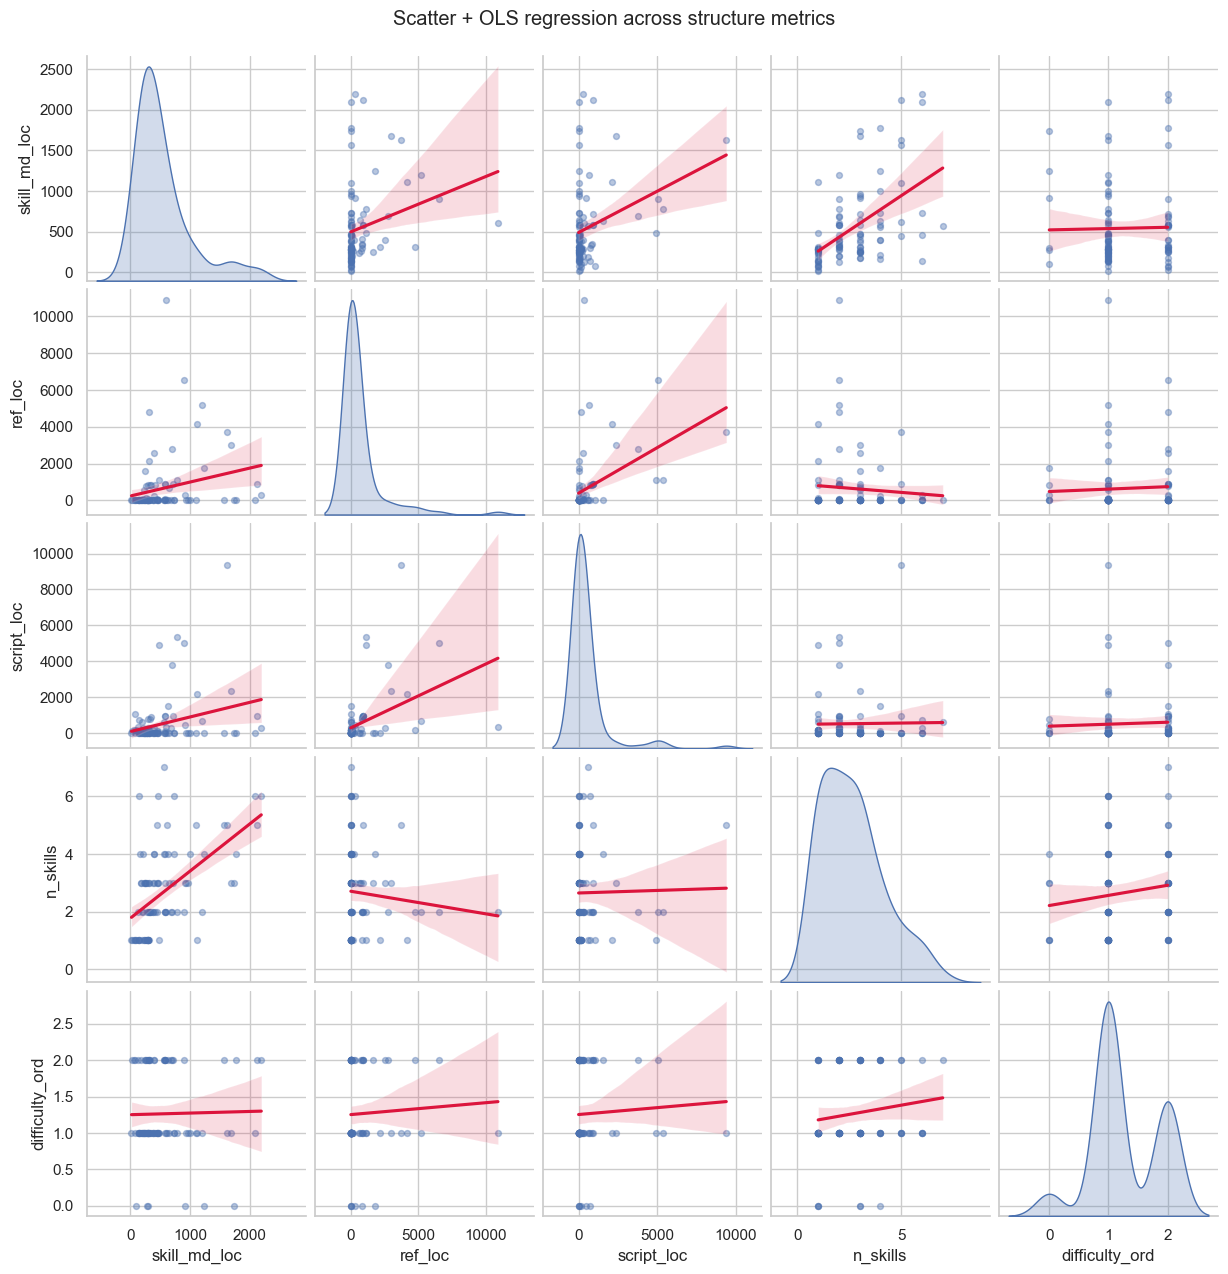

In [3]:
pair_metrics = ["skill_md_loc", "ref_loc", "script_loc", "n_skills", "difficulty_ord"]
g = sns.pairplot(num[pair_metrics].dropna(), kind="reg", diag_kind="kde",
                 plot_kws={"line_kws": {"color": "crimson"},
                           "scatter_kws": {"alpha": 0.4, "s": 18}})
g.figure.suptitle("Scatter + OLS regression across structure metrics", y=1.02)
plt.show()

## Colored by `structure_class`

How the prose-only / mixed / script-heavy groups separate in metric space — the basis for picking eval tasks that span the AIP-upside gradient.

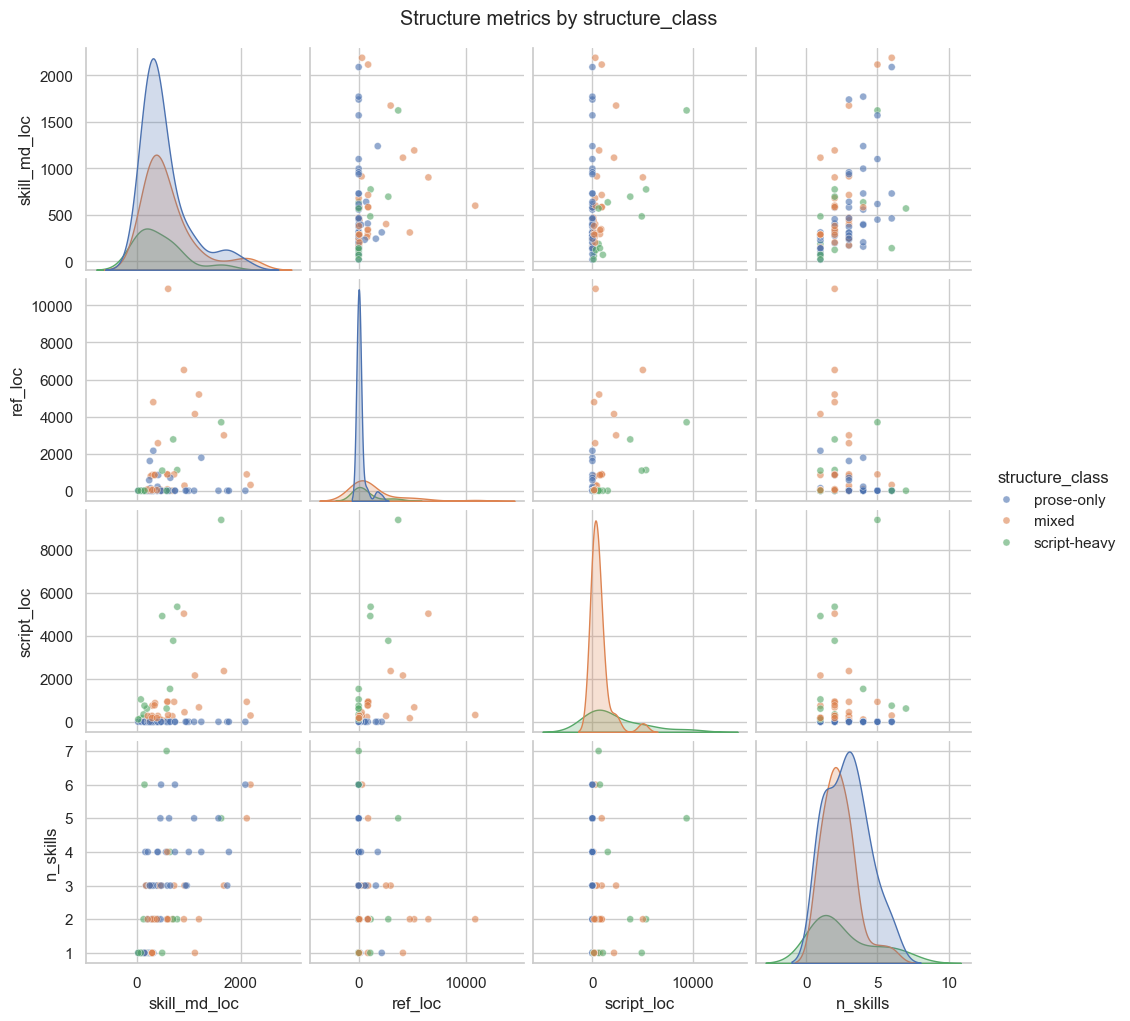

In [4]:
df_num = df.assign(**{m: num[m] for m in pair_metrics})
g2 = sns.pairplot(df_num, vars=["skill_md_loc", "ref_loc", "script_loc", "n_skills"],
                  hue="structure_class", hue_order=["prose-only", "mixed", "script-heavy"],
                  diag_kind="kde", plot_kws={"alpha": 0.6, "s": 26})
g2.figure.suptitle("Structure metrics by structure_class", y=1.02)
plt.show()

## Hypothesized AIP-upside drivers, by difficulty

Working hypothesis: AIP-from-curated's benefit over human-curated is driven by **how much unstructured prose** the human skill carries — i.e. `prose_loc`, `prose_to_code_ratio`, and `skill_md_loc`. (Consistent with the eval-3med deep dives: drone was prose-only → largest gain; crystallographic was prose-heavy → consistency gain.)

> **Caveat:** we can't yet *correlate* these to measured AIP-cur benefit — that needs a per-task `(aip_cur − human)` delta across many tasks, and we have eval data for only 3 so far. These box plots instead show how the candidate driver metrics **distribute within each difficulty tier**, to confirm there's range to sample (i.e. you can pick prose-heavy *and* prose-light tasks at every difficulty). y-axis is log-scaled (the metrics are heavy-tailed). `prose_to_code_ratio` excludes the 50 prose-only tasks (no scripts → ratio undefined; they're the extreme high end by definition).

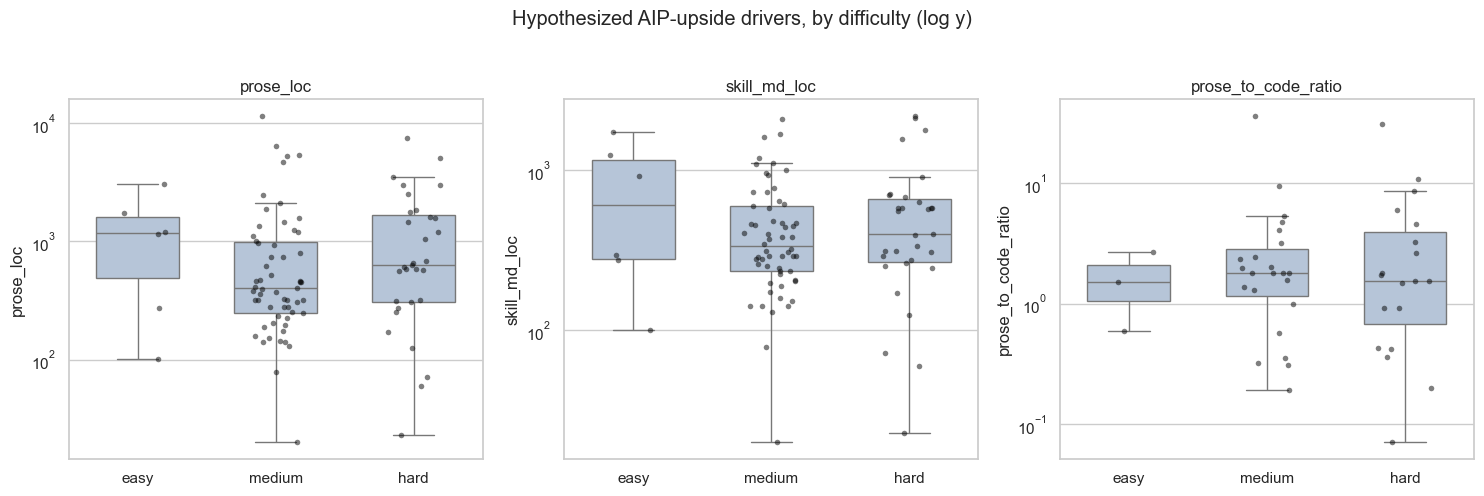

medians by difficulty:
  prose_loc            easy=1167.0  medium=399.5  hard=636.0
  skill_md_loc         easy=605.0  medium=335.5  hard=402.0
  prose_to_code_ratio  easy=1.5  medium=1.8  hard=1.6

prose_to_code_ratio panel covers 45/95 tasks (prose-only excluded).


In [5]:
order = ["easy", "medium", "hard"]
box_metrics = ["prose_loc", "skill_md_loc", "prose_to_code_ratio"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
for ax, metric in zip(axes, box_metrics):
    d = df.copy()
    d[metric] = pd.to_numeric(d[metric], errors="coerce")
    sub = d.dropna(subset=[metric])
    sns.boxplot(data=sub, x="difficulty", y=metric, order=order, ax=ax,
                color="lightsteelblue", fliersize=0, width=0.6)
    sns.stripplot(data=sub, x="difficulty", y=metric, order=order, ax=ax,
                  color="black", alpha=0.5, size=4, jitter=0.2)
    ax.set_yscale("log")
    ax.set_title(metric)
    ax.set_xlabel("")
fig.suptitle("Hypothesized AIP-upside drivers, by difficulty (log y)", y=1.03)
plt.tight_layout()
plt.show()

# medians by difficulty + coverage note for the ratio panel
print("medians by difficulty:")
for m in box_metrics:
    s = df.assign(_v=pd.to_numeric(df[m], errors="coerce")).groupby("difficulty")["_v"].median().reindex(order)
    print(f"  {m:20s} easy={s['easy']:.1f}  medium={s['medium']:.1f}  hard={s['hard']:.1f}")
n_ratio = pd.to_numeric(df["prose_to_code_ratio"], errors="coerce").notna().sum()
print(f"\nprose_to_code_ratio panel covers {n_ratio}/{len(df)} tasks (prose-only excluded).")

## ln-transformed drivers: scatter + regression

The three hypothesized AIP-upside drivers (`prose_loc`, `skill_md_loc`, `prose_to_code_ratio`) are heavy-tailed, so a **natural-log transform** makes their pairwise relationships closer to linear and the OLS lines interpretable.

Two caveats:
- `prose_to_code_ratio` is undefined for the **50 prose-only tasks** (no scripts), so this matrix covers only the **45 with-scripts tasks** (mixed + script-heavy).
- By construction `ln(prose_to_code_ratio) = ln(prose_loc) − ln(script_loc)`, so `ln_prose_to_code_ratio` shares the `prose_loc` term with `ln_prose_loc` — expect some built-in positive association between those two.

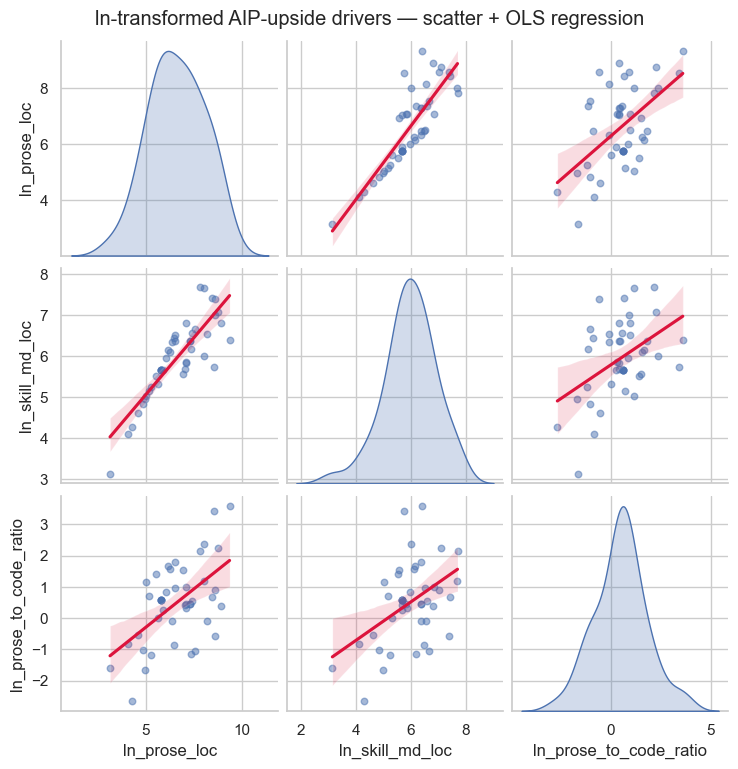

n = 45 tasks (all three defined; 50 prose-only excluded — no ratio)

Pearson correlation on the log scale:
                        ln_prose_loc  ln_skill_md_loc  ln_prose_to_code_ratio
ln_prose_loc                    1.00             0.85                    0.55
ln_skill_md_loc                 0.85             1.00                    0.45
ln_prose_to_code_ratio          0.55             0.45                    1.00


In [6]:
log_src = ["prose_loc", "skill_md_loc", "prose_to_code_ratio"]
logdf = pd.DataFrame({f"ln_{m}": np.log(pd.to_numeric(df[m], errors="coerce")) for m in log_src})
logdf = logdf.replace([np.inf, -np.inf], np.nan).dropna()

g = sns.pairplot(logdf, kind="reg", diag_kind="kde",
                 plot_kws={"line_kws": {"color": "crimson"},
                           "scatter_kws": {"alpha": 0.5, "s": 22}})
g.figure.suptitle("ln-transformed AIP-upside drivers — scatter + OLS regression", y=1.02)
plt.show()

print(f"n = {len(logdf)} tasks (all three defined; 50 prose-only excluded — no ratio)\n")
print("Pearson correlation on the log scale:")
print(logdf.corr().round(2))

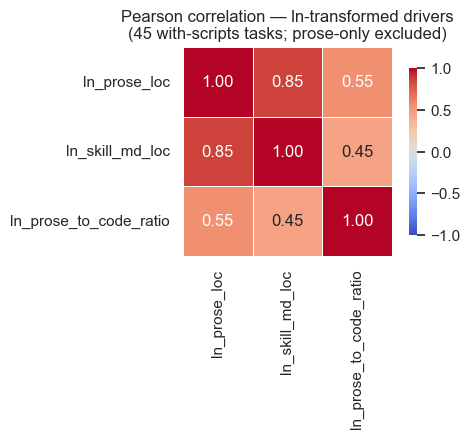

In [7]:
# Correlation heatmap of the ln-transformed drivers (reuses logdf from the cell above)
log_corr = logdf.corr()
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(log_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Pearson correlation — ln-transformed drivers\n(45 with-scripts tasks; prose-only excluded)")
plt.tight_layout()
plt.show()

## What to look for

- **`prose_loc` vs `script_loc`** — independent, or do verbose tasks also script more? Determines whether *prose-only* is a distinct regime AIP can target.
- **`difficulty_ord` correlations** — does structure track difficulty, or is it an independent axis? If independent, sample `structure_class` and `difficulty` separately.
- **`n_skills` vs LoC** — do multi-skill tasks carry proportionally more prose/code?

Use the separation in the colored matrix to choose eval tasks spanning the `structure_class` gradient (prose-only → script-heavy), with difficulty/category as secondary coverage.